<a href="https://colab.research.google.com/github/ilsagandeguay/PCVK-Ganjil-2026/blob/main/Week02/Week02_Tugas%20Praktikum_D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS PRAKTIKUM - PENERAPAN**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.


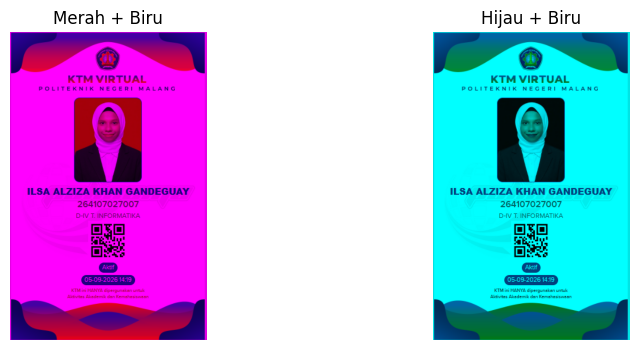

In [6]:
img1 = cv.imread('/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week2/KTM.png')
img2 = cv.imread('/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week2/img2.jpg')

# Merah + Biru, Hijau = 0
RB = img1.copy()
RB[:, :, 1] = 0

# Hijau + Biru, Merah = 0
GB = img1.copy()
GB[:, :, 2] = 0

# Tampilkan
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(RB, cv.COLOR_BGR2RGB))
plt.title("Merah + Biru")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(GB, cv.COLOR_BGR2RGB))
plt.title("Hijau + Biru")
plt.axis("off")

plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing
diberi label.

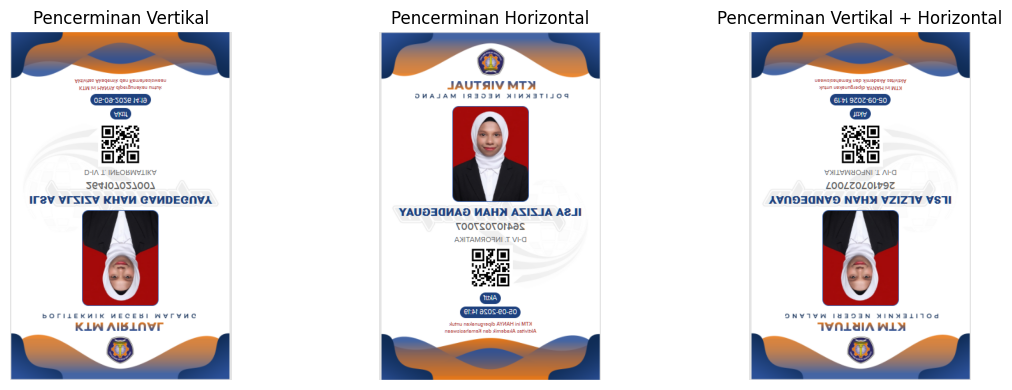

In [7]:
vertikal = cv.flip(img1, 0)
horizontal = cv.flip(img1, 1)
keduanya = cv.flip(img1, -1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(vertikal, cv.COLOR_BGR2RGB))
plt.title("Pencerminan Vertikal")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(horizontal, cv.COLOR_BGR2RGB))
plt.title("Pencerminan Horizontal")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(keduanya, cv.COLOR_BGR2RGB))
plt.title("Pencerminan Vertikal + Horizontal")
plt.axis("off")

plt.tight_layout()
plt.show()

3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

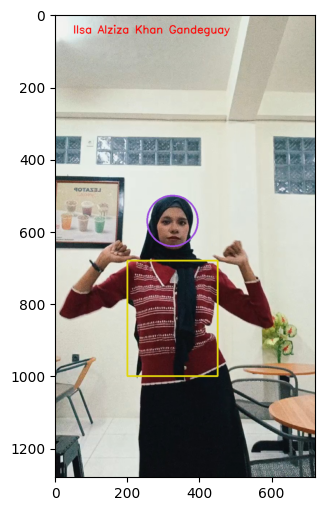

In [8]:
# Placeholder coordinates (adjust as needed for your image)
x1, y1 = 200, 680
x2, y2 = 450, 1000
x, y = 325, 570
radius = 70

# Rectangle pada badan
cv.rectangle(img2, (x1, y1), (x2, y2), (13, 214, 225), 3)

# Circle pada wajah
cv.circle(img2, (x, y), radius, (221, 78, 157), 3)

# Teks nama
cv.putText(img2, "Ilsa Alziza Khan Gandeguay", (50, 50),
           cv.FONT_HERSHEY_SIMPLEX, 1,
           (0, 0, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.axis("on")
plt.show()

**TUGAS PRAKTIKUM - ANALISA**

Pertanyaan :

Apakah melakukan pencerminan horizontal pada sebuah citra mengubah nilai rata-rata intensitas piksel citra tersebut?

Rata-rata intensitas citra asli   : 198.27235579457977
Rata-rata intensitas setelah flip : 198.27235579457977


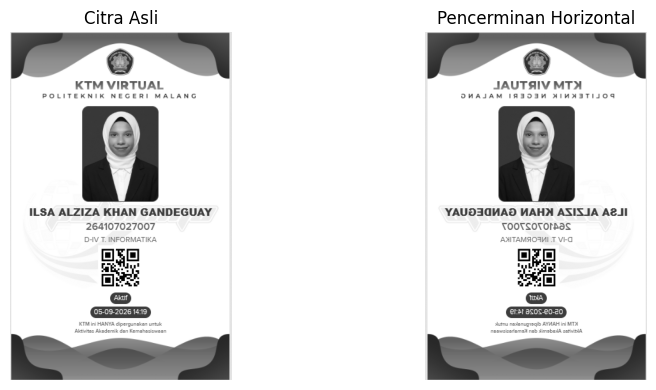

In [9]:
# Mengubah ke grayscale
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)

# Pencerminan horizontal
flip = cv.flip(gray, 1)

# Menghitung rata-rata intensitas
rata_asli = gray.mean()
rata_flip = flip.mean()

print("Rata-rata intensitas citra asli   :", rata_asli)
print("Rata-rata intensitas setelah flip :", rata_flip)

# Menampilkan gambar
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flip, cmap="gray")
plt.title("Pencerminan Horizontal")
plt.axis("off")

plt.tight_layout()
plt.show()

Jawaban:

Berdasarkan hasil pengujian, pencerminan horizontal tidak mengubah nilai rata-rata intensitas citra. Hal ini terlihat dari nilai rata-rata intensitas citra asli dan citra setelah pencerminan yang sama. Pencerminan hanya mengubah posisi piksel dari kiri ke kanan, sedangkan nilai intensitas masing-masing piksel tetap sama.

**TUGAS PRAKTIKUM - APLIKASI**

1. Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama.

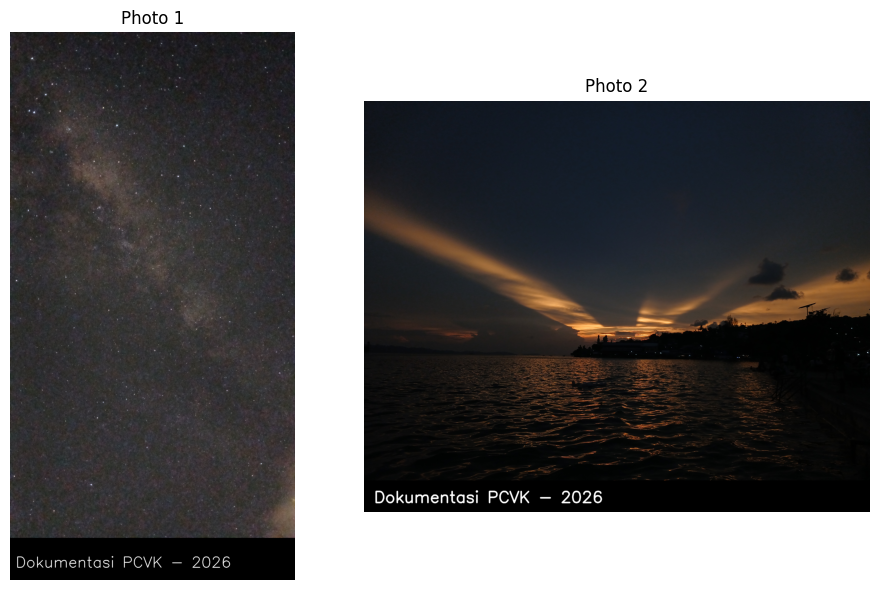

In [10]:
photo1 = cv.imread('/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week2/photo2.jpg')
photo2 = cv.imread('/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week2/photo1.jpg')

# ================= PHOTO 1 =================

# Ukuran foto
H1, W1 = photo1.shape[:2]

tinggi_bar1 = int(H1 / 12)

# Kanvas baru
hasil1 = np.zeros((H1 + tinggi_bar1, W1, 3), dtype=np.uint8)

# Masukkan foto ke kanvas
hasil1[:H1, :W1] = photo1

# Ukuran teks menyesuaikan tinggi bar
ukuran1 = tinggi_bar1 / 85
tebal1 = max(1, int(tinggi_bar1 / 60))

# Teks pada bar
cv.putText(
    hasil1,
    "Dokumentasi PCVK - 2026",
    (int(W1 / 50), H1 + int(tinggi_bar1 * 0.7)),
    cv.FONT_HERSHEY_SIMPLEX,
    ukuran1,
    (255, 255, 255),
    tebal1
)


# ================= PHOTO 2 =================
H2, W2 = photo2.shape[:2]

tinggi_bar2 = int(H2 / 12)

# Kanvas baru
hasil2 = np.zeros((H2 + tinggi_bar2, W2, 3), dtype=np.uint8)

# Masukkan foto ke kanvas
hasil2[:H2, :W2] = photo2

# Ukuran teks menyesuaikan tinggi bar
ukuran2 = tinggi_bar2 / 60
tebal2 = max(1, int(tinggi_bar2 / 20))

# Teks pada bar
cv.putText(
    hasil2,
    "Dokumentasi PCVK - 2026",
    (int(W2 / 50), H2 + int(tinggi_bar2 * 0.7)),
    cv.FONT_HERSHEY_SIMPLEX,
    ukuran2,
    (255, 255, 255),
    tebal2
)


# Menampilkan
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(hasil1, cv.COLOR_BGR2RGB))
plt.title("Photo 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil2, cv.COLOR_BGR2RGB))
plt.title("Photo 2")
plt.axis("off")

plt.tight_layout()
plt.show()

2. Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas, tambahkan logo nama toko berukuran proporsional pada gambar.

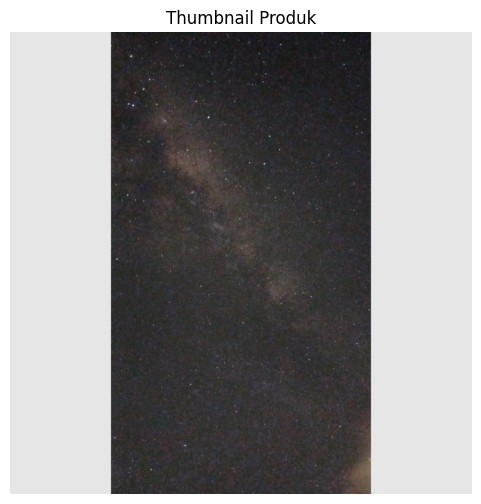

In [12]:
# Membaca ukuran foto
H, W = photo1.shape[:2]

# Menentukan ukuran thumbnail persegi
S = max(H, W)

# Membuat kanvas persegi berwarna
thumbnail = np.zeros((S, S, 3), dtype=np.uint8)

# Warna kanvas
thumbnail[:] = (230, 230, 230)

# Menentukan ukuran foto agar rasio tetap
if H > W:
    tinggi = S
    lebar = int(W * S / H)
else:
    lebar = S
    tinggi = int(H * S / W)

# Resize foto
foto_resize = cv.resize(photo1, (lebar, tinggi))

# Menentukan posisi agar tepat di tengah
x = int((S - lebar) / 2)
y = int((S - tinggi) / 2)

# Menempatkan foto di tengah kanvas
thumbnail[y:y+tinggi, x:x+lebar] = foto_resize

# Ukuran tulisan proporsional
ukuran = S / 600
tebal = max(1, int(S / 300))

# Menampilkan hasil
plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(thumbnail, cv.COLOR_BGR2RGB))
plt.title("Thumbnail Produk")
plt.axis("off")
plt.show()